# Binary Classification with CNNs: pneumonia_MNIST Data Set

## Setup

In [1]:
import tensorflow as tf
import datetime

notebook_start_time = datetime.datetime.now()

I0000 00:00:1782456690.925944 1511392 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782456692.651409 1511392 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# load the dataset
import tensorflow_datasets as tfds

train_ds, validation_ds, test_ds = tfds.load(
    "pneumonia_mnist", split=["train", "val", "test"], as_supervised=True
)

batch_size = 32
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]


def make_callbacks(filepath):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_loss", mode="min"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


epochs = 10

# images are batched, so we need to extract them
y_true = tf.concat([y for x, y in test_ds], axis=0)

In [3]:
from visualization import summary_graphics


def get_class_training_weights(assignments, normalize=True):
    # inverse-frequency weighting: up-weight the MINORITY class
    n_total = len(assignments)
    n_pos = float(sum(assignments))  # number of class-1 (pneumonia) labels
    n_neg = n_total - n_pos  # number of class-0 (normal) labels
    weight_0 = n_total / (2 * n_neg)
    weight_1 = n_total / (2 * n_pos)
    if normalize:
        denom = max(weight_0, weight_1)
        weight_0 = weight_0 / denom
        weight_1 = weight_1 / denom
    return {0: weight_0, 1: weight_1}

In [4]:
class_weight = get_class_training_weights(tf.concat([y for x, y in train_ds], axis=0))

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.347


## Training

In [5]:
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1000, activation="relu", name="5.2dense"),
        tf.keras.layers.Dense(500, activation="relu", name="5.4dense"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_1",
)

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_1.summary()

Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 5.1flatten (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,001 (4.91 MB)

 Trainable params: 1,286,001 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adam_1.keras"),
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8526 - loss: 2.0636 - precision: 0.9447 - recall: 0.8512 - tn: 1040.0000 - tp: 2974.0000 - val_accuracy: 0.8130 - val_loss: 3.6076 - val_precision: 1.0000 - val_recall: 0.7481 - val_tn: 135.0000 - val_tp: 291.0000 - learning_rate: 1.0000e-04
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8951 - loss: 1.0275 - precision: 0.9630 - recall: 0.8930 - tn: 1094.0000 - tp: 3120.0000 - val_accuracy: 0.9485 - val_loss: 0.6824 - val_precision: 0.9714 - val_recall: 0.9589 - val_tn: 124.0000 - val_tp: 373.0000 - learning_rate: 1.0000e-04
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8912 - loss: 1.1400 - precision: 0.9616 - recall: 0.8890 - tn: 1090.0000 - tp: 3106.0000 - val_accuracy: 0.8511 - val_loss: 2.7089 - val_precision: 1.0000 - val_recall: 0.7995 - val_tn: 135.0000 - val_tp: 311.0000 - learning_rate: 1.0000e-04
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9089 - loss: 0.93

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


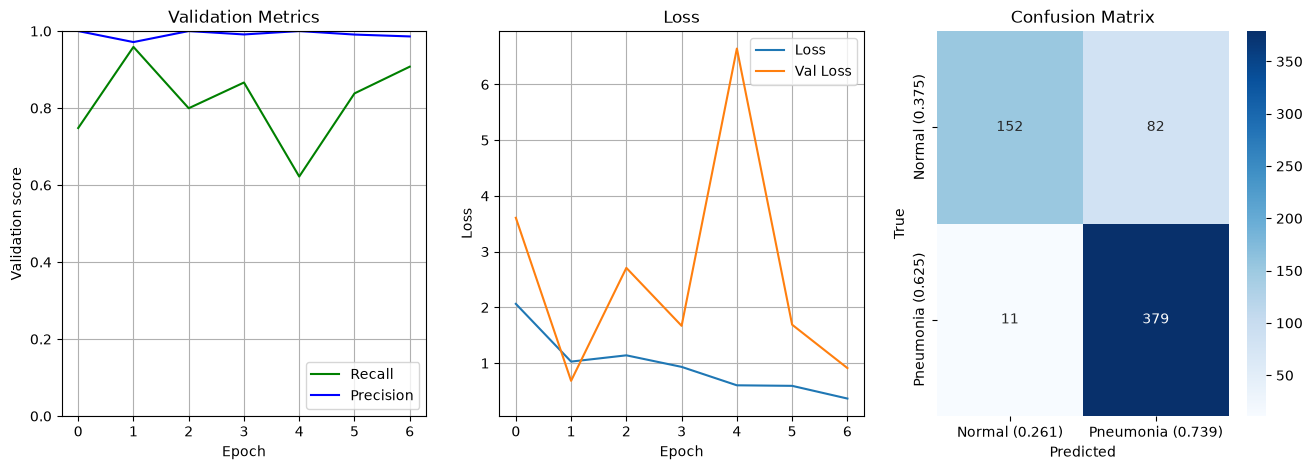

In [7]:
summary_graphics(history, model_1, test_ds)

In [8]:
# try something similar to xception, but with fewer filters and layers
# to account for how small these images are
model_2 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_2",
)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_2.summary()

Model: "Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0.1rflip (RandomFlip)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.2rrot (RandomRotation)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.3rtran (RandomTranslation)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.1conv (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.2conv (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.3pool (MaxPooling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.1conv (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.2conv (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.3pool (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.1conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.2batchnorm                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.3conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.4pool (MaxPooling2D)          │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.1conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.2batchnorm                    │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.3conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.6pool (MaxPooling2D)          │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.3dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.5dropout (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           25

 Total params: 296,657 (1.13 MB)

 Trainable params: 296,401 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

In [9]:
history = model_2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adam_2.keras"),
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.4922 - loss: 0.3569 - precision: 0.8321 - recall: 0.3956 - tn: 1039.0000 - tp: 1536.0000 - val_accuracy: 0.2576 - val_loss: 0.6940 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 135.0000 - val_tp: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.7387 - loss: 0.2727 - precision: 0.9272 - recall: 0.7032 - tn: 1021.0000 - tp: 2457.0000 - val_accuracy: 0.8664 - val_loss: 0.6429 - val_precision: 0.8753 - val_recall: 0.9563 - val_tn: 82.0000 - val_tp: 372.0000 - learning_rate: 1.0000e-04
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8418 - loss: 0.1787 - precision: 0.9508 - recall: 0.8297 - tn: 1064.0000 - tp: 2899.0000 - val_accuracy: 0.7347 - val_loss: 0.6184 - val_precision: 1.0000 - val_recall: 0.6427 - val_tn: 135.0000 - val_tp: 250.0000 - learning_rate: 1.0000e-04
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8543 - 

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


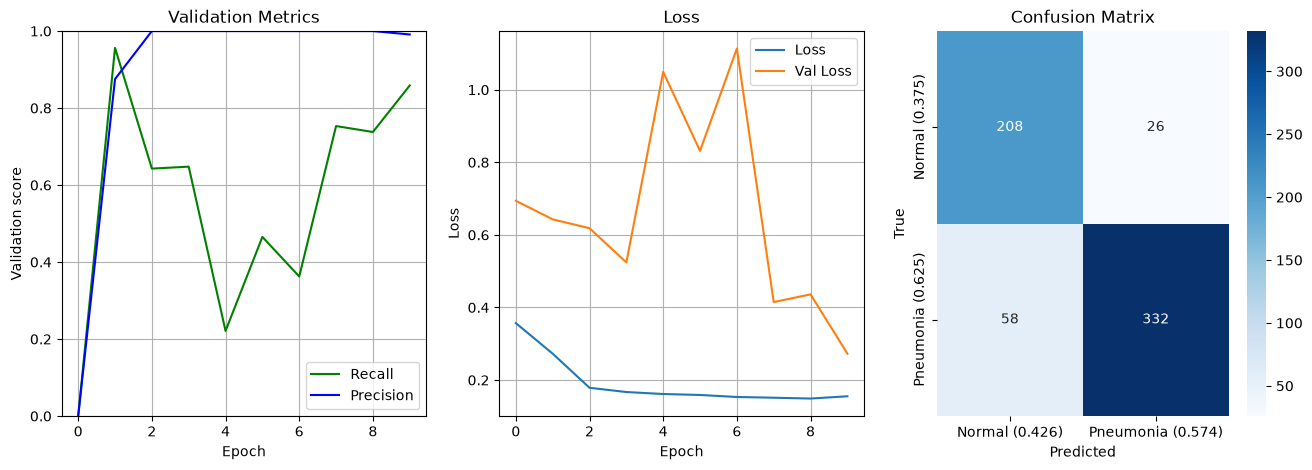

In [10]:
summary_graphics(history, model_2, test_ds)

In [11]:
# model accuracy seems to be capping out, so let's lower dropout slightly
model_3 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_3",
)

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.6495 - loss: 0.3384 - precision: 0.8824 - recall: 0.6088 - tn: 1034.0000 - tp: 2364.0000 - val_accuracy: 0.7424 - val_loss: 0.6589 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000 - learning_rate: 1.0000e-04
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.8320 - loss: 0.1854 - precision: 0.9483 - recall: 0.8183 - tn: 1058.0000 - tp: 2859.0000 - val_accuracy: 0.7424 - val_loss: 0.5695 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000 - learning_rate: 1.0000e-04
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.8551 - loss: 0.1675 - precision: 0.9559 - recall: 0.8437 - tn: 1078.0000 - tp: 2948.0000 - val_accuracy: 0.7443 - val_loss: 0.4882 - val_precision: 0.7438 - val_recall: 1.0000 - val_tn: 1.0000 - val_tp: 389.0000 - learning_rate: 1.0000e-04
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8581 - loss: 0

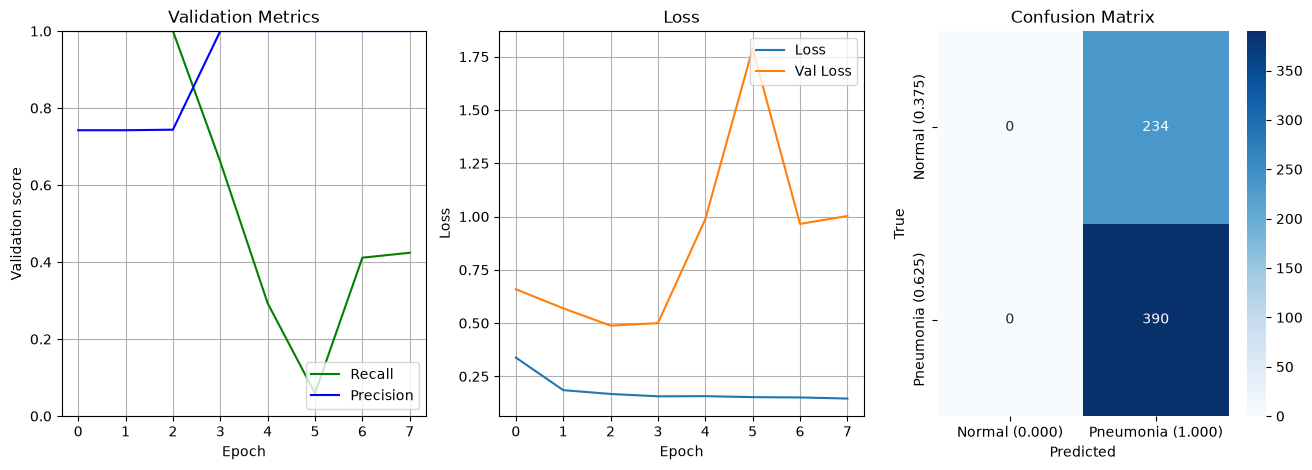

In [12]:
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adam_3.keras"),
)
summary_graphics(history, model_3, test_ds)

Epoch 1/20
  5/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8625 - loss: 0.1512 - precision: 0.9434 - recall: 0.8621 - tn: 38.0000 - tp: 100.0000

/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8615 - loss: 0.1534 - precision: 0.9563 - recall: 0.8523 - tn: 1078.0000 - tp: 2978.0000 - val_accuracy: 0.8893 - val_loss: 0.3621 - val_precision: 0.9742 - val_recall: 0.8740 - val_tn: 126.0000 - val_tp: 340.0000 - learning_rate: 5.0000e-05
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8660 - loss: 0.1559 - precision: 0.9596 - recall: 0.8555 - tn: 1088.0000 - tp: 2989.0000 - val_accuracy: 0.5458 - val_loss: 0.8582 - val_precision: 1.0000 - val_recall: 0.3882 - val_tn: 135.0000 - val_tp: 151.0000 - learning_rate: 5.0000e-05
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8643 - loss: 0.1533 - precision: 0.9597 - recall: 0.8529 - tn: 1089.0000 - tp: 2980.0000 - val_accuracy: 0.6298 - val_loss: 0.8019 - val_precision: 1.0000 - val_recall: 0.5013 - val_tn: 135.0000 - val_tp: 195.0000 - learning_rate: 5.0000e-05
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8709 - loss: 0.14

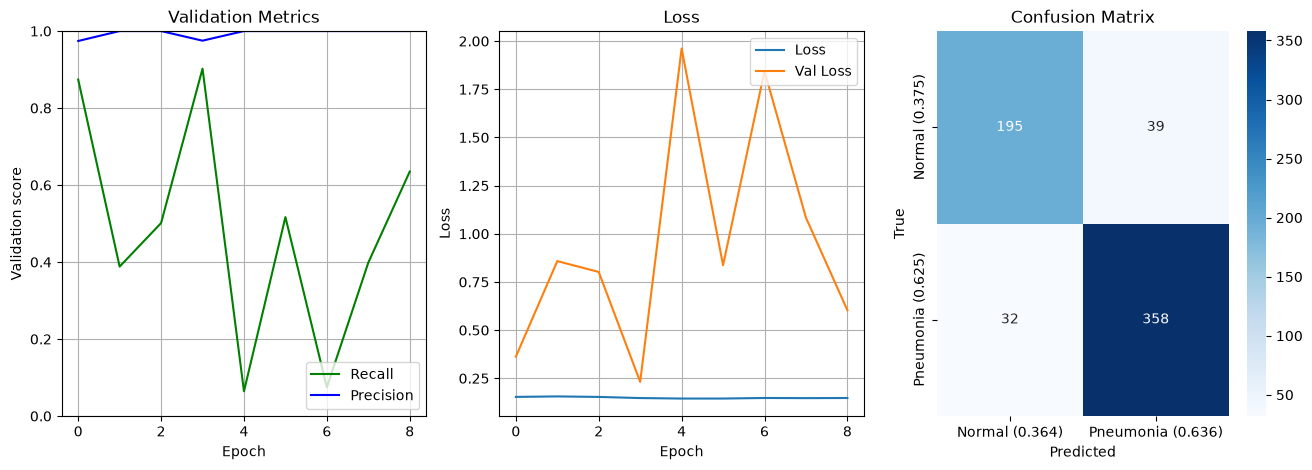

In [13]:
# maybe more epochs will help
epochs = 20
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adam_3.keras"),
)
summary_graphics(history, model_3, test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


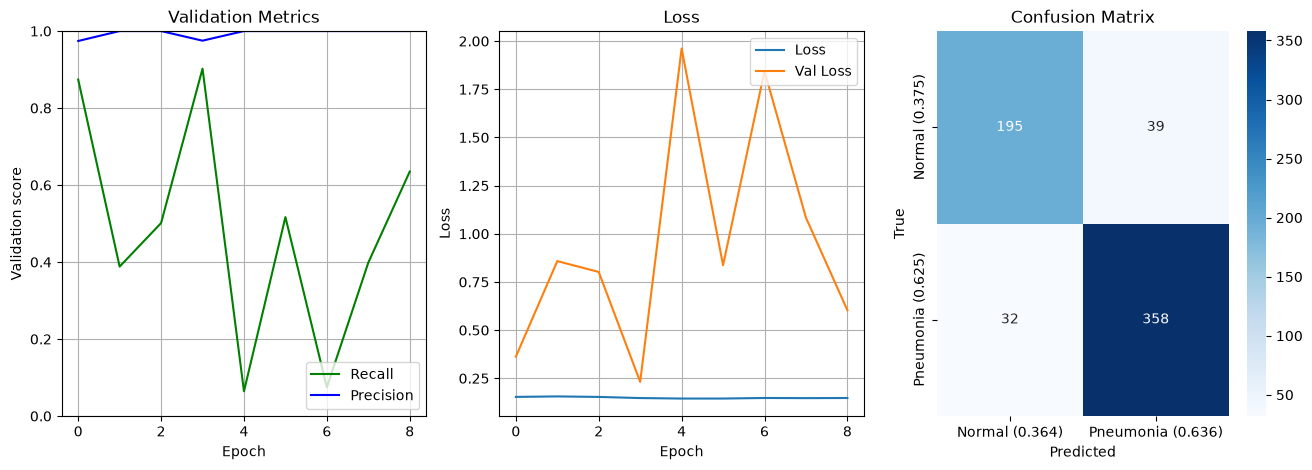

In [14]:
best_model = tf.keras.models.load_model("best_model_adam_3.keras")
summary_graphics(history, best_model, test_ds)

In [15]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-06-26 02:55:47.816258 (duration: 0:04:12.251767)
